In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer

sns.set_theme(style="whitegrid")

In [29]:
# Load the final dataset
df = pd.read_csv("../data/leetcode_final.csv")
print(df['Searchable_Text'].isna().sum())
df['Searchable_Text'] = df['Searchable_Text'].fillna("")
df.head()


0


,ID,title,slug,difficulty,Topics,Searchable_Text,Similar Questions,Link,Code_Skeleton,Clean_Similar,content
0,1,Two Sum,two-sum,Easy,"Array, Hash Table","two sum two sum two sum array, hash table def ...","[{""title"": ""3Sum"", ""titleSlug"": ""3sum"", ""diffi...",https://leetcode.com/problems/two-sum/,"def twoSum(nums, target): map = {} complement ...",3Sum 4Sum Two Sum II - Input Array Is Sorted T...,Given an array of integers `nums` and an integ...
1,2,Add Two Numbers,add-two-numbers,Medium,"Linked List, Math, Recursion",add two numbers add two numbers add two number...,"[{""title"": ""Multiply Strings"", ""titleSlug"": ""m...",https://leetcode.com/problems/add-two-numbers/,"class ListNode: def __init__(self, val=0, next...",Multiply Strings Add Binary Sum of Two Integer...,You are given two **non-empty** linked lists r...
2,3,Longest Substring Without Repeating Characters,longest-substring-without-repeating-characters,Medium,"Hash Table, String, Sliding Window",longest substring without repeating characters...,"[{""title"": ""Longest Substring with At Most Two...",https://leetcode.com/problems/longest-substrin...,def length_of_longest_substring(s: str) -> int...,Longest Substring with At Most Two Distinct Ch...,"Given a string `s`, find the length of the **l..."
3,4,Median of Two Sorted Arrays,median-of-two-sorted-arrays,Hard,"Array, Binary Search, Divide and Conquer",median of two sorted arrays median of two sort...,"[{""title"": ""Median of a Row Wise Sorted Matrix...",https://leetcode.com/problems/median-of-two-so...,"def findMedianSortedArrays(nums1, nums2): x, y...",Median of a Row Wise Sorted Matrix,Given two sorted arrays `nums1` and `nums2` of...
4,5,Longest Palindromic Substring,longest-palindromic-substring,Medium,"Two Pointers, String, Dynamic Programming",longest palindromic substring longest palindro...,"[{""title"": ""Shortest Palindrome"", ""titleSlug"":...",https://leetcode.com/problems/longest-palindro...,def longest_palindromic_substring(s: str) -> s...,Shortest Palindrome Palindrome Permutation Pal...,"Given a string `s`, return _the longest_ _pali..."


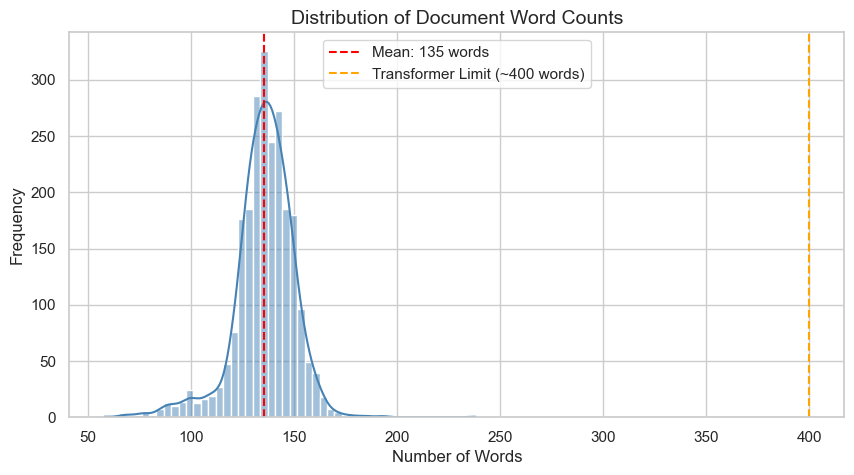

In [30]:
# TEXT LENGTH (TOKEN) DISTRIBUTION
df['Word_Count'] = df['Searchable_Text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
sns.histplot(df['Word_Count'], bins=50, color='steelblue', kde=True)
plt.axvline(df['Word_Count'].mean(), color='red', linestyle='dashed', label=f"Mean: {int(df['Word_Count'].mean())} words")
plt.axvline(400, color='orange', linestyle='dashed', label="Transformer Limit (~400 words)")
plt.title("Distribution of Document Word Counts", fontsize=14)
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.legend()
plt.show()

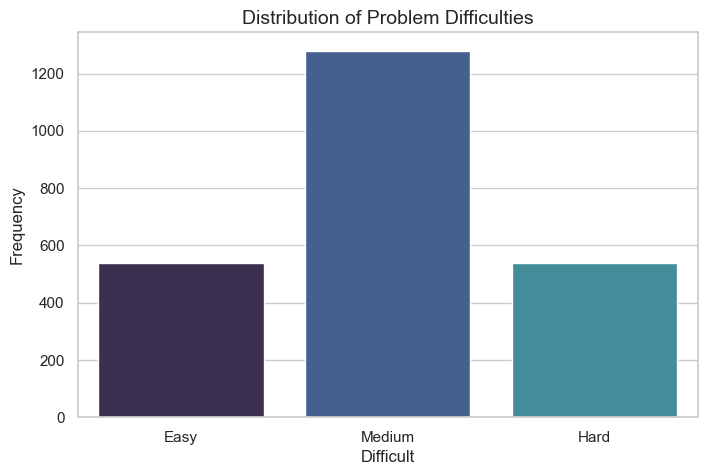

In [31]:
# DIFFICULTY DISTRIBUTION
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='difficulty', order=['Easy', 'Medium', 'Hard'], palette='mako', hue='difficulty', legend=False)
plt.title("Distribution of Problem Difficulties", fontsize=14)
plt.xlabel("Difficult")
plt.ylabel("Frequency")
plt.show()

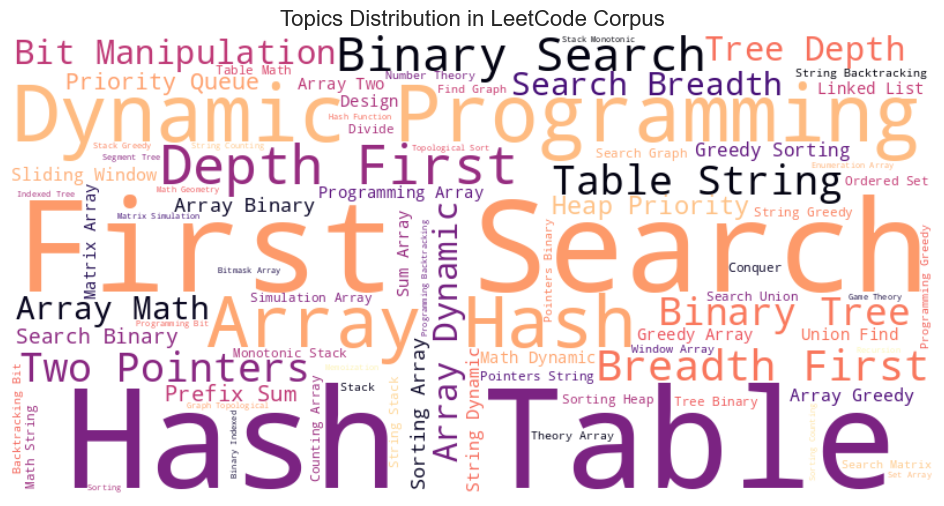

In [32]:
# Topics Distribution
all_text = " ".join(df['Topics'].tolist())
wordcloud = WordCloud(width=800, height=400, background_color='white', 
                      max_words=80, colormap='magma').generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Topics Distribution in LeetCode Corpus", fontsize=16)
plt.show()

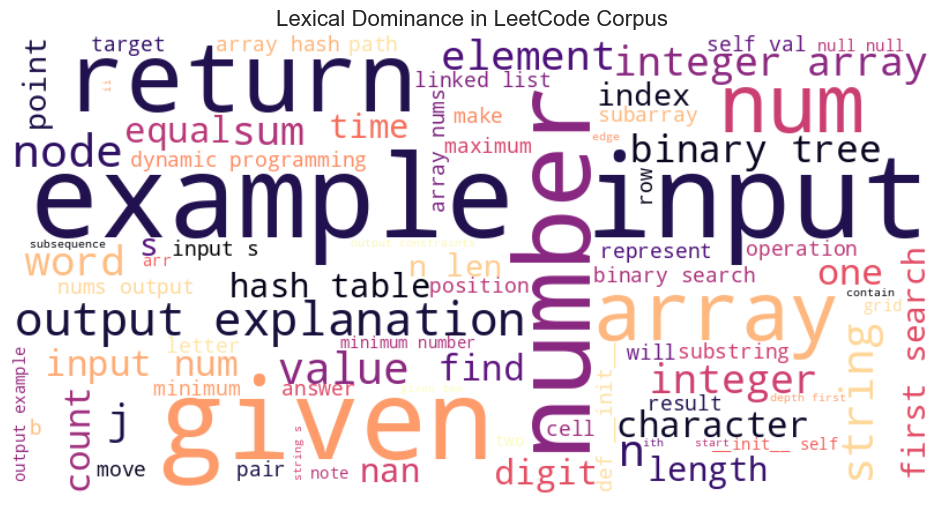

In [33]:
# LEXICAL NOISE (WORD CLOUD)
all_text = " ".join(df['Searchable_Text'].tolist())
wordcloud = WordCloud(width=800, height=400, background_color='white', 
                      max_words=80, colormap='magma').generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Lexical Dominance in LeetCode Corpus", fontsize=16)
plt.show()

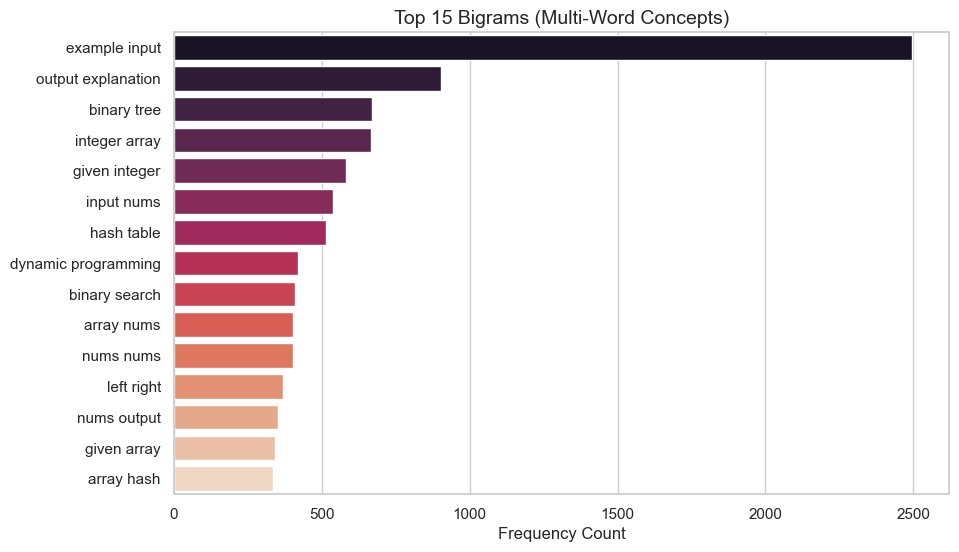

In [34]:
# DOMAIN SEMANTICS (BIGRAMS)
def get_top_ngram(corpus, n=None, ngram_range=(2, 2)):
    vec = CountVectorizer(ngram_range=ngram_range, stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

top_bigrams = get_top_ngram(df['Searchable_Text'], n=15)
x_labels = [val[0] for val in top_bigrams]
y_values = [val[1] for val in top_bigrams]

plt.figure(figsize=(10, 6))
sns.barplot(x=y_values, y=x_labels, palette='rocket', hue=x_labels, legend=False)
plt.title("Top 15 Bigrams (Multi-Word Concepts)", fontsize=14)
plt.xlabel("Frequency Count")
plt.show()